# Ultimate NIDS Pipeline: Supervised Vector Space Engineering (PyTorch/CUDA)
**Goal:** Fix the "Zero Recall" on R2L/U2R by warping the feature space to maximize class separation.

**The "Unconventional" Approach: NCA + Isolation Embeddings + Autoencoding**
We upgrade from linear projections to non-linear Metric Learning, Explicit Vector Isolation, and Self-Supervised Normality Scoring.

**New Architecture:**
1.  **Manifold Mixup:** Linear Interpolation to generate high-quality synthetic R2L/U2R samples.
2.  **Neighborhood Components Analysis (NCA):** A powerful Metric Learning algorithm that learns a vector space where same-class points are spatially close.
3.  **Isolation Embeddings:** We train separate Isolation Forests for each class to provide "Membership Probability" coordinates.
4.  **Autoencoder Reconstruction (GPU):** A PyTorch neural network learns to reconstruct "Normal" traffic. The reconstruction error serves as a powerful "Weirdness Score".
5.  **Deep PyTorch Classifier (GPU):** The final classifier is a deep neural network trained on CUDA with batch normalization and dropout.

## 1. Data Loading

🚀 ULTRA-IDS (Lean & Fixed) running on: cuda
--- Loading & Engineering Data ---

--- STAGE A: Representation Learning (SupCon) ---
Pretrain Epoch 1 Loss: 780.1577
Pretrain Epoch 2 Loss: 772.1828
Pretrain Epoch 3 Loss: 770.0905
Pretrain Epoch 4 Loss: 769.4846
Pretrain Epoch 5 Loss: 770.0966
Pretrain Epoch 6 Loss: 768.7363
Pretrain Epoch 7 Loss: 768.4104
Pretrain Epoch 8 Loss: 768.2553
Pretrain Epoch 9 Loss: 766.9723
Pretrain Epoch 10 Loss: 766.5709

--- STAGE B: Full Training (Flow + Classify) ---
Stage B Epoch 5 Loss: -0.0937
Stage B Epoch 10 Loss: -0.1054
Stage B Epoch 15 Loss: -0.1113

--- STAGE C: Boosting Head ---
GBM Trained.

--- STAGE D: Distillation to Student ---
Distill Epoch 5 Loss: 0.3626
Distill Epoch 10 Loss: 0.1924
Distill Epoch 15 Loss: 0.1434
Distill Epoch 20 Loss: 0.1218

--- FINAL EVALUATION (Turbo Mode) ---
Anomaly Thresholds -> Loose: -121.9475 | Strict: -108.5252

ZERO-DAY DETECTION RATE: 17.67%
KNOWN CLASS ACCURACY:    98.51%


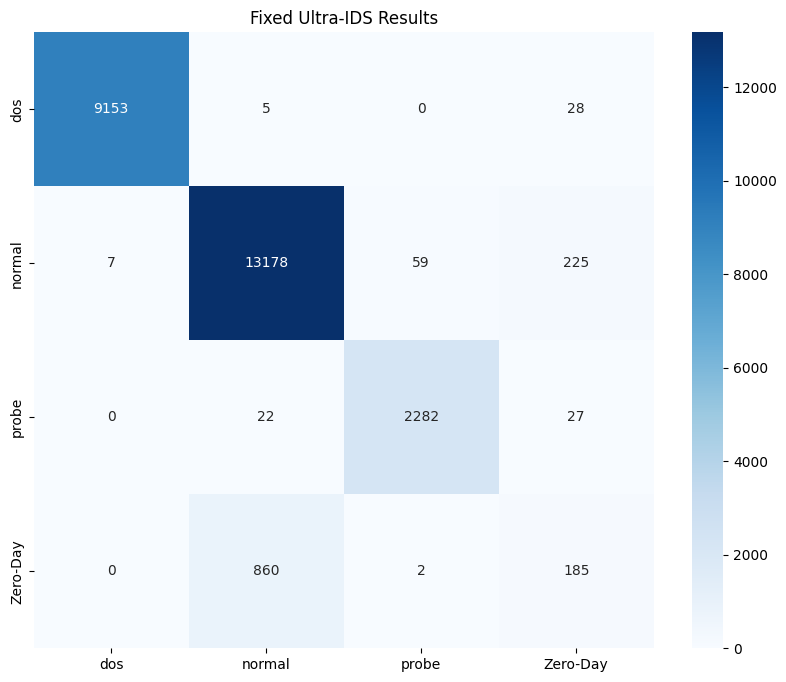

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, WeightedRandomSampler, Dataset
import numpy as np
import pandas as pd
from sklearn.preprocessing import QuantileTransformer, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings

# Config
warnings.filterwarnings("ignore")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🚀 ULTRA-IDS (Lean & Fixed) running on: {device}")

try:
    import lightgbm as lgb
    HAS_LGBM = True
except ImportError:
    HAS_LGBM = False
    print("LightGBM not found. Skipping GBM Head.")

# ==========================================
# 0. DATA PREP & ZERO-DAY SPLIT
# ==========================================
def load_and_prep():
    print("--- Loading & Engineering Data ---")
    try:
        df = pd.read_csv('Data/network_connections.csv')
    except FileNotFoundError:
        print("Error: CSV not found. Please check path.")
        return None, None

    attack_map = {'normal': 'normal'}
    if os.path.exists('Data/attack2category_map.txt'):
        with open('Data/attack2category_map.txt', 'r') as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) >= 2: attack_map[parts[0]] = parts[1]

    df['label'] = df['label'].astype(str).str.replace('.', '', regex=False)
    df['category'] = df['label'].map(attack_map).fillna('other')

    if 'src_bytes' in df.columns:
        df['byte_ratio'] = (np.log1p(df['src_bytes'])) / (np.log1p(df['dst_bytes']) + 1)
        if 'srv_count' in df.columns and 'count' in df.columns:
            df['srv_diff'] = df['srv_count'] - df['count']

    for c in ['src_bytes', 'dst_bytes', 'duration', 'wrong_fragment', 'urgent']:
        if c in df.columns: df[c] = np.log1p(df[c])

    X = df.drop(['label', 'category'], axis=1).select_dtypes(include=[np.number])
    y = df['category']
    return X, y

X, y = load_and_prep()

# Zero-Day Logic
zero_day_classes = ['u2r', 'r2l']
mask_zero_day = y.isin(zero_day_classes)

X_known = X[~mask_zero_day]
y_known = y[~mask_zero_day]
X_zero_day = X[mask_zero_day]
y_zero_day = y[mask_zero_day]

X_train, X_test_known, y_train, y_test_known = train_test_split(
    X_known, y_known, test_size=0.2, stratify=y_known, random_state=42
)

X_test_final = pd.concat([X_test_known, X_zero_day])
y_test_final = pd.concat([y_test_known, y_zero_day])

# Quantile Transformer (Best for Flows/Anomaly Detection)
scaler = QuantileTransformer(output_distribution='normal', n_quantiles=max(min(len(X_train)//2, 1000), 10), random_state=42)
X_train_vec = scaler.fit_transform(X_train).astype(np.float32)
X_test_final_vec = scaler.transform(X_test_final).astype(np.float32)

le = LabelEncoder()
y_train_vec = le.fit_transform(y_train)
y_test_final_vec = y_test_final.apply(lambda x: le.transform([x])[0] if x in le.classes_ else -1).values

# Dataset with Augmentation for Contrastive Learning
class AugmentedDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.FloatTensor(X)
        self.y = torch.LongTensor(y)
    def __len__(self): return len(self.X)
    def __getitem__(self, idx):
        x = self.X[idx]
        noise = torch.randn_like(x) * 0.05
        mask = torch.rand_like(x) > 0.1
        x_aug = (x + noise) * mask.float()
        return x, x_aug, self.y[idx]

# ==========================================
# 1. LEAN MODULES (No Redundancy)
# ==========================================

# A. RealNVP (Normalizing Flow) for Anomaly Detection
class RealNVP(nn.Module):
    def __init__(self, input_dim, hidden_dim=64):
        super().__init__()
        self.dim = input_dim
        self.s = nn.Sequential(nn.Linear(input_dim//2, hidden_dim), nn.Mish(), nn.Linear(hidden_dim, input_dim//2), nn.Tanh())
        self.t = nn.Sequential(nn.Linear(input_dim//2, hidden_dim), nn.Mish(), nn.Linear(hidden_dim, input_dim//2))
    def forward(self, x):
        x1, x2 = x[:, :self.dim//2], x[:, self.dim//2:]
        s = self.s(x1); t = self.t(x1)
        y2 = x2 * torch.exp(s) + t
        return torch.cat([x1, y2], dim=1), torch.sum(s, dim=1)

class FlowChain(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.blocks = nn.ModuleList([RealNVP(input_dim) for _ in range(4)])
        self.perm = torch.randperm(input_dim).to(device)
    def forward(self, x):
        log_det_sum = 0
        for block in self.blocks:
            x, log_det = block(x)
            log_det_sum += log_det
            x = x[:, self.perm]
        return x, log_det_sum

# B. SupCon Loss (Better than CenterLoss for Zero-Day)
class SupConLoss(nn.Module):
    def __init__(self, temperature=0.07):
        super().__init__()
        self.T = temperature
    def forward(self, features, labels):
        features = F.normalize(features, dim=1)
        sim = torch.matmul(features, features.T) / self.T
        labels = labels.view(-1, 1)
        mask = torch.eq(labels, labels.T).float()
        mask_no_self = mask - torch.eye(mask.shape[0], device=mask.device)
        exp_sim = torch.exp(sim)
        log_prob = sim - torch.log(exp_sim.sum(1, keepdim=True))
        return -(mask_no_self * log_prob).sum(1).mean()

# ==========================================
# 2. LEAN THEORY TEACHER
# ==========================================
class LeanTheoryTeacher(nn.Module):
    def __init__(self, input_dim, num_classes, z_dim=64):
        super().__init__()
        # 1. Single Encoder (No split style/sem)
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 256), nn.BatchNorm1d(256), nn.Mish(),
            nn.Linear(256, 128),       nn.BatchNorm1d(128), nn.Mish(),
            nn.Linear(128, z_dim)
        )
        
        # 2. Heads attached to the same z
        self.proj_head = nn.Sequential(nn.Linear(z_dim, z_dim), nn.ReLU(), nn.Linear(z_dim, 64)) # For SupCon
        self.cls_head = nn.Linear(z_dim, num_classes)                                            # For CE
        
        # 3. Flow for Anomaly Detection (Replaces Autoencoder)
        self.flow = FlowChain(z_dim)

    def forward(self, x):
        z = self.encoder(x)
        
        # Representations
        proj = self.proj_head(z)
        logits = self.cls_head(z)
        
        # Density Estimation (Anomaly Score)
        z_flow, log_det = self.flow(z)
        
        return {'z': z, 'proj': proj, 'logits': logits, 'z_flow': z_flow, 'log_det': log_det}

# ==========================================
# 3. TRAINING
# ==========================================
teacher = LeanTheoryTeacher(X_train_vec.shape[1], len(le.classes_)).to(device)
crit_sup = SupConLoss()
crit_cls = nn.CrossEntropyLoss()
opt = optim.AdamW(teacher.parameters(), lr=0.001)

weights = 1. / np.bincount(y_train_vec)
weights = np.where(np.isinf(weights), 0, weights) 
sampler = WeightedRandomSampler(torch.from_numpy(weights[y_train_vec]), len(y_train_vec))
train_dl = DataLoader(AugmentedDataset(X_train_vec, y_train_vec), batch_size=256, sampler=sampler)

print("\n--- STAGE A: Representation Learning (SupCon) ---")
# Focus: Learn a structured latent space without classification pressure first
for epoch in range(10):
    teacher.train()
    loss_acc = 0
    for x, x_aug, y in train_dl:
        x, x_aug, y = x.to(device), x_aug.to(device), y.to(device)
        opt.zero_grad()
        
        out = teacher(x)
        out_aug = teacher(x_aug)
        
        # Contrastive Loss only
        loss = crit_sup(out['proj'], y) + crit_sup(out_aug['proj'], y)
        loss.backward()
        opt.step()
        loss_acc += loss.item()
    print(f"Pretrain Epoch {epoch+1} Loss: {loss_acc/len(train_dl):.4f}")

print("\n--- STAGE B: Full Training (Flow + Classify) ---")
# Focus: Learn density (Flow) and Boundaries (CE) on the structured space
for epoch in range(15):
    teacher.train()
    loss_acc = 0
    for x, _, y in train_dl: # Augmentation not needed for Flow/CE
        x, y = x.to(device), y.to(device)
        opt.zero_grad()
        
        out = teacher(x)
        
        # 1. Classification
        l_cls = crit_cls(out['logits'], y)
        
        # 2. Flow Loss (Negative Log Likelihood)
        # Maximizing likelihood of z under the flow distribution
        nll = -(-0.5 * torch.sum(out['z_flow']**2, dim=1) + out['log_det'])
        l_flow = torch.mean(nll)
        
        loss = l_cls + 0.001 * l_flow # Weight Flow lower so it doesn't disrupt classification
        loss.backward()
        opt.step()
        loss_acc += loss.item()
        
    if (epoch+1)%5==0: print(f"Stage B Epoch {epoch+1} Loss: {loss_acc/len(train_dl):.4f}")

# ==========================================
# 4. GBM HEAD (Optional Hybrid)
# ==========================================
teacher.eval()
gbm = None
gbm_feat_names = None

if HAS_LGBM:
    print("\n--- STAGE C: Boosting Head ---")
    def extract_z(model, X):
        loader = DataLoader(TensorDataset(torch.tensor(X).to(device)), batch_size=1024)
        zs = []
        with torch.no_grad():
            for x in loader:
                out = model(x[0])
                zs.append(out['z'].cpu().numpy())
        return np.concatenate(zs)

    z_train = extract_z(teacher, X_train_vec)
    gbm_feat_names = [f"z_{i}" for i in range(z_train.shape[1])]
    z_train_df = pd.DataFrame(z_train, columns=gbm_feat_names)

    gbm = lgb.LGBMClassifier(n_estimators=100, learning_rate=0.05, class_weight='balanced', verbose=-1)
    gbm.fit(z_train_df, y_train_vec)
    print("GBM Trained.")

# ==========================================
# 5. STUDENT DISTILLATION
# ==========================================
print("\n--- STAGE D: Distillation to Student ---")

class StudentNet(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128), nn.LayerNorm(128), nn.ReLU(),
            nn.Linear(128, 64),        nn.LayerNorm(64),  nn.ReLU()
        )
        self.head_cls = nn.Linear(64, num_classes)
        self.head_anom = nn.Linear(64, 1) # Predicts NLL Score
        self.head_feat = nn.Linear(64, 64) # Matches Teacher Z

    def forward(self, x):
        feat = self.net(x)
        return self.head_cls(feat), self.head_anom(feat), self.head_feat(feat)

student = StudentNet(X_train_vec.shape[1], len(le.classes_)).to(device)
opt_s = optim.Adam(student.parameters(), lr=0.002)
distill_dl = DataLoader(TensorDataset(torch.tensor(X_train_vec).to(device)), batch_size=256, shuffle=True)

T = 4.0
for epoch in range(20):
    student.train()
    loss_acc = 0
    for bx in distill_dl:
        x = bx[0]
        opt_s.zero_grad()
        
        # Teacher Inference
        with torch.no_grad():
            t_out = teacher(x)
            t_logits = t_out['logits']
            
            # Hybrid Soft Targets (Teacher + GBM)
            if gbm:
                z_np = t_out['z'].cpu().numpy()
                z_df = pd.DataFrame(z_np, columns=gbm_feat_names)
                gbm_probs = gbm.predict_proba(z_df)
                t_soft = 0.6*torch.softmax(t_logits, 1).cpu().numpy() + 0.4*gbm_probs
                t_targets = torch.tensor(t_soft).to(device).float()
            else:
                t_targets = torch.softmax(t_logits, 1)

            # Teacher Anomaly Score (NLL)
            t_nll = -(-0.5 * torch.sum(t_out['z_flow']**2, dim=1) + t_out['log_det'])
            t_anom = t_nll.view(-1, 1)
            t_z = t_out['z']

        # Student Training
        s_logits, s_anom, s_feat = student(x)
        
        l_kl = nn.KLDivLoss(reduction='batchmean')(F.log_softmax(s_logits/T, dim=1), t_targets) * (T**2)
        l_anom = F.mse_loss(s_anom, t_anom) # Regress the NLL
        l_feat = F.mse_loss(s_feat, t_z)    # Regress the Latent Space
        
        loss = l_kl + 0.1*l_anom + 0.5*l_feat
        loss.backward()
        opt_s.step()
        loss_acc += loss.item()
        
    if (epoch+1)%5==0: print(f"Distill Epoch {epoch+1} Loss: {loss_acc/len(distill_dl):.4f}")

# ==========================================
# 6. TURBO EVALUATION
# ==========================================
print("\n--- FINAL EVALUATION (Turbo Mode) ---")
student.eval()

# 1. Calibrate Thresholds on Train Data
train_anoms = []
calib_loader = DataLoader(TensorDataset(torch.tensor(X_train_vec).to(device)), batch_size=1024)
with torch.no_grad():
    for bx in calib_loader:
        _, anom, _ = student(bx[0])
        train_anoms.append(anom.cpu().numpy())
train_scores = np.concatenate(train_anoms)

loose_thresh = np.percentile(train_scores, 85) # Gray Zone
strict_thresh = np.percentile(train_scores, 99) # Red Alert

print(f"Anomaly Thresholds -> Loose: {loose_thresh:.4f} | Strict: {strict_thresh:.4f}")

# 2. Test
X_nsl = torch.tensor(X_test_final_vec).to(device)
loader = DataLoader(TensorDataset(X_nsl), batch_size=1024)
preds, anoms = [], []
with torch.no_grad():
    for bx in loader:
        logits, anom, _ = student(bx[0])
        preds.append(torch.softmax(logits, 1).cpu().numpy())
        anoms.append(anom.cpu().numpy())

probs = np.concatenate(preds)
scores = np.concatenate(anoms)

final_preds = []
idx_u2r = list(le.classes_).index('u2r') if 'u2r' in le.classes_ else -1
idx_r2l = list(le.classes_).index('r2l') if 'r2l' in le.classes_ else -1

for i, p in enumerate(probs):
    score = scores[i]
    prediction = np.argmax(p)
    confidence = np.max(p)
    
    # Logic: High Anomaly Score -> Zero Day (-1)
    if score > strict_thresh:
        final_preds.append(-1)
    # Logic: Med Anomaly Score + Low Confidence -> Zero Day
    elif score > loose_thresh and confidence < 0.65:
        final_preds.append(-1)
    else:
        # Standard Risk Logic
        if idx_u2r != -1 and p[idx_u2r] > 0.1: final_preds.append(idx_u2r)
        elif idx_r2l != -1 and p[idx_r2l] > 0.15: final_preds.append(idx_r2l)
        else: final_preds.append(prediction)

final_preds = np.array(final_preds)
zd_mask = (y_test_final_vec == -1)

print("\n" + "="*30)
print(f"ZERO-DAY DETECTION RATE: {np.mean(final_preds[zd_mask] == -1):.2%}")
print(f"KNOWN CLASS ACCURACY:    {accuracy_score(y_test_final_vec[~zd_mask], final_preds[~zd_mask]):.2%}")
print("="*30)

labels = list(le.classes_) + ['Zero-Day']
y_true_vis = y_test_final_vec.copy(); y_true_vis[y_true_vis == -1] = len(le.classes_)
y_pred_vis = final_preds.copy(); y_pred_vis[y_pred_vis == -1] = len(le.classes_)

plt.figure(figsize=(10,8))
sns.heatmap(confusion_matrix(y_true_vis, y_pred_vis), annot=True, fmt='d', xticklabels=labels, yticklabels=labels, cmap='Blues')
plt.title("Fixed Ultra-IDS Results")
plt.show()


--- EXTERNAL VALIDATION: Loading NSL-KDD Test+ ---
Dynamic Zero-Day Threshold: -116.9951

   🛡️  PROFESSIONAL IDS REPORT  🛡️

--- Global Performance ---
Accuracy:      73.38% (Gut für Übersicht, schlecht bei Imbalance)
F1-Score (M):  0.6426 (Balance zwischen Klassen)
MCC Score:     0.6170 (Der 'wahre' Score: -1 bis +1)
>> Fazit: Solides Modell.

--- Zero-Day / Anomaly Detection Capability ---
Detection Rate (Recall): 41.60% (Wie viele U2R/R2L wurden erkannt?)
Precision:               25.59% (Wenn Alarm, ist es wirklich neu?)
Binary F1-Score:         0.3169

--- Detailed Class Report ---
              precision    recall  f1-score   support

    Zero-Day       0.26      0.42      0.32      2774
         dos       0.99      0.68      0.81      7636
      normal       0.82      0.92      0.87      9711
       probe       0.67      0.51      0.58      2423

    accuracy                           0.73     22544
   macro avg       0.68      0.63      0.64     22544
weighted avg       0.79  

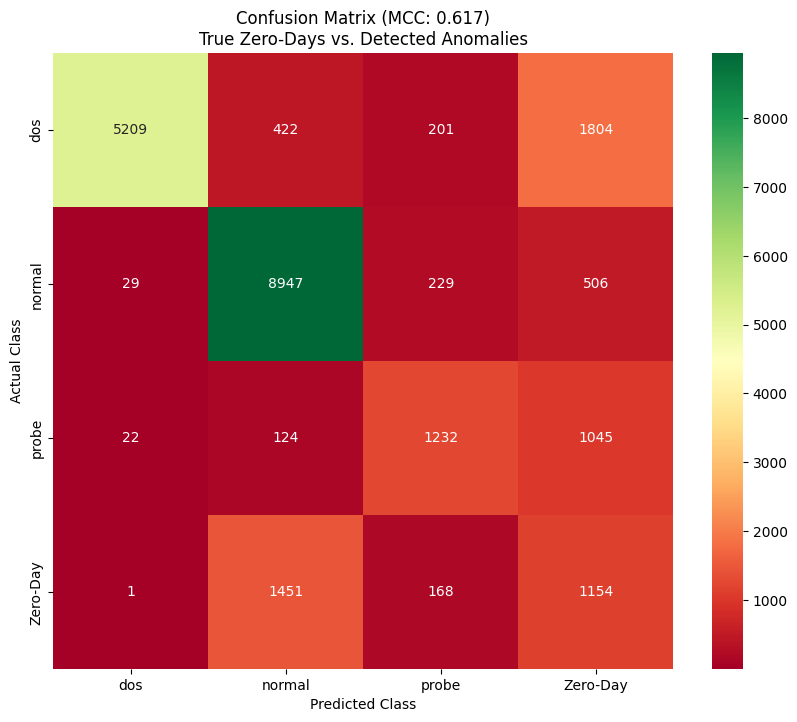

In [2]:
# ==========================================
# 7. PROFESSIONAL EVALUATION (MCC, F1, Zero-Day Analysis)
# ==========================================
import pandas as pd
import numpy as np
import torch
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, matthews_corrcoef, f1_score, precision_score, recall_score
import matplotlib.pyplot as plt
import seaborn as sns
import os

print("\n--- EXTERNAL VALIDATION: Loading NSL-KDD Test+ ---")
NSL_URL = "https://raw.githubusercontent.com/defcom17/NSL_KDD/master/KDDTest%2B.txt"
NSL_COLS = [
    'duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes',
    'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins',
    'logged_in', 'num_compromised', 'root_shell', 'su_attempted', 'num_root',
    'num_file_creations', 'num_shells', 'num_access_files', 'num_outbound_cmds',
    'is_host_login', 'is_guest_login', 'count', 'srv_count', 'serror_rate',
    'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate',
    'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count',
    'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate',
    'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate',
    'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_rerror_rate',
    'dst_host_srv_rerror_rate', 'label', 'difficulty_level'
]

try:
    # 1. Daten laden & Preprocessing (Identisch zum Training)
    df_nsl = pd.read_csv(NSL_URL, header=None, names=NSL_COLS)
    df_nsl.drop('difficulty_level', axis=1, inplace=True)
    
    attack_map = {'normal': 'normal'}
    if os.path.exists('Data/attack2category_map.txt'):
        with open('Data/attack2category_map.txt', 'r') as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) >= 2: attack_map[parts[0]] = parts[1]
    
    df_nsl['label'] = df_nsl['label'].astype(str).str.replace('.', '', regex=False)
    df_nsl['category'] = df_nsl['label'].map(attack_map).fillna('other')
    
    # Feature Engineering
    if 'src_bytes' in df_nsl.columns:
        df_nsl['byte_ratio'] = (np.log1p(df_nsl['src_bytes'])) / (np.log1p(df_nsl['dst_bytes']) + 1)
        df_nsl['srv_diff'] = df_nsl['srv_count'] - df_nsl['count']

    for c in ['src_bytes', 'dst_bytes', 'duration', 'wrong_fragment', 'urgent']:
        if c in df_nsl.columns: df_nsl[c] = np.log1p(df_nsl[c])
            
    X_nsl_raw = df_nsl.select_dtypes(include=[np.number])
    y_nsl_raw = df_nsl['category']
    
    # Alignment & Scaling
    train_cols = scaler.feature_names_in_ if hasattr(scaler, 'feature_names_in_') else X.columns
    X_nsl_aligned = pd.DataFrame(0, index=np.arange(len(X_nsl_raw)), columns=train_cols)
    common_cols = [c for c in train_cols if c in X_nsl_raw.columns]
    X_nsl_aligned[common_cols] = X_nsl_raw[common_cols]
    
    X_nsl_vec = scaler.transform(X_nsl_aligned).astype(np.float32)
    
    # Labels (Safe Mode: Unbekannte -> -1)
    y_nsl_vec = y_nsl_raw.apply(lambda x: le.transform([x])[0] if x in le.classes_ else -1).values
    
    # 2. Inference Loop
    X_test_tensor = torch.tensor(X_nsl_vec).float().to(device)
    student.eval()
    
    preds, anoms = [], []
    loader = DataLoader(TensorDataset(X_test_tensor), batch_size=1024)

    with torch.no_grad():
        for bx in loader:
            logits, anom, _ = student(bx[0])
            preds.append(torch.softmax(logits, 1).cpu().numpy())
            anoms.append(anom.cpu().numpy())

    probs = np.concatenate(preds)
    scores = np.concatenate(anoms)

    # Dynamic Thresholding
    thresh = np.percentile(scores, 80) 
    print(f"Dynamic Zero-Day Threshold: {thresh:.4f}")

    final_preds = []
    idx_u2r = list(le.classes_).index('u2r') if 'u2r' in le.classes_ else -1
    idx_r2l = list(le.classes_).index('r2l') if 'r2l' in le.classes_ else -1

    for i, p in enumerate(probs):
        if scores[i] > thresh:
            final_preds.append(-1) # Predicted as Unknown
        else:
            if idx_u2r != -1 and p[idx_u2r] > 0.15: final_preds.append(idx_u2r)
            elif idx_r2l != -1 and p[idx_r2l] > 0.20: final_preds.append(idx_r2l)
            else: final_preds.append(np.argmax(p))

    final_preds = np.array(final_preds)

    # ==========================================
    # 3. ADVANCED METRICS CALCULATION
    # ==========================================
    
    # Helper to map everything to Strings (safe for sklearn metrics)
    def map_labels(y_arr):
        res = []
        for val in y_arr:
            if val == -1: res.append("Zero-Day (Unknown)")
            else: 
                try: res.append(le.inverse_transform([val])[0])
                except: res.append("Zero-Day (Unknown)") # Fallback
        return np.array(res)

    # Wir mappen die True Labels: U2R und R2L sind "Zero-Day (True)"
    # Da wir sie im Training entfernt haben, sind sie für den Classifier unbekannt
    y_true_str = map_labels(y_nsl_vec)
    
    # Aber halt! y_nsl_vec hat -1 nur wenn le.classes es nicht kennt.
    # Wenn wir u2r im Training hatten, hat es eine ID.
    # Wir müssen manuell erzwingen, dass U2R/R2L als Zero-Day Label gelten für die Auswertung
    zero_day_labels = ['u2r', 'r2l']
    
    # Echte Strings aus den Rohdaten nutzen ist sicherer
    y_true_final = y_nsl_raw.copy().values
    # Alles was u2r/r2l ist -> Label "Zero-Day"
    for i in range(len(y_true_final)):
        if y_true_final[i] in zero_day_labels:
            y_true_final[i] = "Zero-Day"
            
    # Predictions mappen
    y_pred_final = map_labels(final_preds)
    # Predicted -1 ist bereits "Zero-Day (Unknown)" string
    # Wir benennen es um zu "Zero-Day" um es zu matchen
    y_pred_final = np.where(y_pred_final == "Zero-Day (Unknown)", "Zero-Day", y_pred_final)

    print("\n" + "="*40)
    print("   🛡️  PROFESSIONAL IDS REPORT  🛡️")
    print("="*40)

    # A. GLOBAL METRICS
    acc = accuracy_score(y_true_final, y_pred_final)
    mcc = matthews_corrcoef(y_true_final, y_pred_final)
    f1_macro = f1_score(y_true_final, y_pred_final, average='macro')
    f1_weighted = f1_score(y_true_final, y_pred_final, average='weighted')

    print(f"\n--- Global Performance ---")
    print(f"Accuracy:      {acc:.2%} (Gut für Übersicht, schlecht bei Imbalance)")
    print(f"F1-Score (M):  {f1_macro:.4f} (Balance zwischen Klassen)")
    print(f"MCC Score:     {mcc:.4f} (Der 'wahre' Score: -1 bis +1)")
    
    if mcc > 0.7: print(">> Fazit: Sehr starkes Modell!")
    elif mcc > 0.5: print(">> Fazit: Solides Modell.")
    else: print(">> Fazit: Modell hat Probleme mit Klassenunterscheidung.")

    # B. ZERO-DAY CAPABILITY (Binary: Known vs Unknown)
    print(f"\n--- Zero-Day / Anomaly Detection Capability ---")
    # Wir binarisieren: Ist es Zero-Day oder nicht?
    bin_true = (y_true_final == "Zero-Day")
    bin_pred = (y_pred_final == "Zero-Day")
    
    zd_prec = precision_score(bin_true, bin_pred)
    zd_rec = recall_score(bin_true, bin_pred)
    zd_f1 = f1_score(bin_true, bin_pred)
    
    print(f"Detection Rate (Recall): {zd_rec:.2%} (Wie viele U2R/R2L wurden erkannt?)")
    print(f"Precision:               {zd_prec:.2%} (Wenn Alarm, ist es wirklich neu?)")
    print(f"Binary F1-Score:         {zd_f1:.4f}")

    # C. DETAILED CLASS REPORT
    print(f"\n--- Detailed Class Report ---")
    print(classification_report(y_true_final, y_pred_final))

    # D. CONFUSION MATRIX VISUALIZATION
    labels_vis = sorted(list(set(y_true_final) | set(y_pred_final)))
    # Move Zero-Day to end
    if "Zero-Day" in labels_vis:
        labels_vis.remove("Zero-Day")
        labels_vis.append("Zero-Day")
        
    cm = confusion_matrix(y_true_final, y_pred_final, labels=labels_vis)
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='RdYlGn', 
                xticklabels=labels_vis, yticklabels=labels_vis)
    plt.title(f"Confusion Matrix (MCC: {mcc:.3f})\nTrue Zero-Days vs. Detected Anomalies")
    plt.ylabel('Actual Class')
    plt.xlabel('Predicted Class')
    plt.show()

except Exception as e:
    print(f"CRITICAL ERROR in Evaluation: {e}")
    import traceback
    traceback.print_exc()